# 目标检测 Notebook

本 Notebook 实现基于微调模型的图像目标检测功能。

## 功能特点
1. **模型加载** - 支持加载微调后的模型权重
2. **图像输入** - 支持本地路径和网络URL两种方式
3. **目标检测** - 识别用户指定的目标类别
4. **可视化** - 在原图上绘制检测框和标签

---

## 0. 环境配置与依赖安装

In [1]:
import json
import os
import sys
import traceback
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# -- Bootstrap: 将项目根目录加入 sys.path (必须在 unsloth_finetune 导入之前) --
_nb_file = globals().get("__vsc_ipynb_file__", "")
_bootstrap_starts = [Path.cwd()] + ([Path(_nb_file).parent] if _nb_file else [])
for _start in _bootstrap_starts:
    for _candidate in [_start] + list(_start.parents):
        if (_candidate / "pyproject.toml").exists():
            if str(_candidate) not in sys.path:
                sys.path.insert(0, str(_candidate))
            break

from unsloth_finetune.notebooking.vision_shared import print_torch_runtime_info

warnings.filterwarnings("ignore")

try:
    import torch

    print_torch_runtime_info(torch, "PyTorch 版本")
except ImportError:
    print("请先安装 PyTorch: pip install torch")
    sys.exit(1)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch 版本: 2.10.0+cu128
GPU: NVIDIA RTX 5880 Ada Generation
VRAM: 47.4 GB
CUDA版本: 12.8


In [2]:
try:
    import matplotlib.font_manager as fm
    import matplotlib.pyplot as plt
    import numpy as np
    import requests
    from PIL import Image

    from unsloth_finetune.notebooking.vision_shared import configure_matplotlib_for_chinese

    configure_matplotlib_for_chinese(plt, fm, warn=True)
    print("图像处理库导入成功")
except ImportError as e:
    print(f"缺少依赖: {e}")
    print("请安装: pip install pillow matplotlib requests")
    sys.exit(1)


警告: 未找到中文字体, 图表中文可能显示为方块
图像处理库导入成功


## 1. 配置参数

修改以下配置单元格中的参数即可适配不同环境。所有路径基于 `PROJECT_ROOT` 自动推导。

**跨Notebook参数关联:**
- `BASE_MODEL_PATH`: 与 **02-微调** Notebook 中的基础模型路径保持一致
- `LORA_ADAPTER_PATH`: 由 **02-微调** Notebook 生成的 LoRA 适配器路径
- `PROMPT_FORMAT`: 推理时的检测prompt格式应与训练数据格式对齐
  - `normalized_xyxy` 对齐 `box_2d_json` 格式的训练数据
  - `legacy_1000x1000` 对齐 `labelme_text` 格式的训练数据
- `COORD_ORDER`: 坐标顺序，必须与 `PROMPT_FORMAT` 匹配
- `COORD_NORM`: 坐标归一化模式
  - `auto`: 自动检测 (推荐) — 根据坐标值范围自动判断
  - `norm_1`: 0-1 归一化坐标
  - `norm_1000`: 0-1000 坐标空间
  - `raw`: 原始像素坐标

In [ ]:
# ============================================================
# 项目路径与全局配置
# ============================================================
# 【重要】修改以下参数即可适配不同环境，无需改动其他单元格

from unsloth_finetune.notebooking.common import initialize_notebook_context

NOTEBOOK_CONTEXT = initialize_notebook_context(notebook_file=_nb_file, cwd=Path.cwd())
NOTEBOOK_DIR = NOTEBOOK_CONTEXT["NOTEBOOK_DIR"]
PROJECT_ROOT = NOTEBOOK_CONTEXT["PROJECT_ROOT"]

# ---------- 模型路径配置 ----------
# 基础模型路径 (与02-微调Notebook中的BASE_MODEL_PATH一致)
# BASE_MODEL_PATH = "unsloth/gemma-4-E4B-it-bnb-4bit"  # HuggingFace在线模型 (推荐)
BASE_MODEL_PATH = "/raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit"
# BASE_MODEL_PATH = str(PROJECT_ROOT / "models" / "base" / "gemma-4-E4B-it-unsloth-bnb-4bit")  # 本地路径

# LoRA适配器路径 (由02-微调Notebook生成)
LORA_ADAPTER_PATH = str(PROJECT_ROOT / "models" / "finetuned" / "gemma4_e4b_lora" / "single/20260523_175429")

# ---------- 模型加载参数 ----------
MAX_SEQ_LENGTH = 2048  # 最大序列长度
LOAD_IN_4BIT = True  # 是否使用4-bit量化
DEVICE_MAP = "cuda:0"  # 设备映射 (可选: "cuda:0", "balanced", "auto")

# ---------- 推理参数 ----------
INFERENCE_MAX_NEW_TOKENS = 512  # 推理最大生成token数
INFERENCE_TEMPERATURE = 0.7  # 推理温度 (越高越随机, 取值范围: 0-2)
INFERENCE_TOP_P = 0.9  # 推理top_p (nucleus sampling, 取值范围: 0-1)

# ---------- 检测格式配置 ----------
PROMPT_FORMAT = "normalized_xyxy"  # 检测prompt格式: "normalized_xyxy" (推荐) 或 "legacy_1000x1000"
COORD_ORDER = "xyxy"               # 坐标顺序: "xyxy" (配合normalized_xyxy) 或 "yxxy" (配合legacy_1000x1000)
COORD_NORM = "auto"                # 坐标归一化模式: "auto"(自动检测), "norm_1"(0-1), "norm_1000"(0-1000), "raw"(像素)

# ---------- 测试数据配置 ----------
TEST_IMAGE_URL = "https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823"
TEST_QUERY = "检测图中的水面绿藻, 使用green algae作为标签"
TEST_OUTPUT_PATH = "test_detection_result.jpg"

print(f"项目根目录: {PROJECT_ROOT}")
print(f"基础模型: {BASE_MODEL_PATH}")
print(f"LoRA适配器: {LORA_ADAPTER_PATH}")
print(f"检测格式: {PROMPT_FORMAT} (坐标顺序: {COORD_ORDER}, 归一化: {COORD_NORM})")

## 2. 模型配置

所有模型路径参数已在上方 **0. 配置参数** 单元格中集中定义，`MODEL_CONFIG` 自动读取这些值。

In [4]:
# ============================================================
# 模型路径配置 — 所有参数已在上方配置单元格中集中定义
# ============================================================

MODEL_CONFIG = {
    "base_model_path": BASE_MODEL_PATH,
    "lora_adapter_path": LORA_ADAPTER_PATH,
    "max_seq_length": MAX_SEQ_LENGTH,
    "load_in_4bit": LOAD_IN_4BIT,
    "device_map": DEVICE_MAP,
}

print("模型配置:")
for key, value in MODEL_CONFIG.items():
    print(f"  {key}: {value}")

模型配置:
  base_model_path: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
  lora_adapter_path: /raid5/sh/code/unsloth-finetune/models/finetuned/gemma4_e4b_lora/single/20260523_175429
  max_seq_length: 2048
  load_in_4bit: True
  device_map: cuda:0


## 3. 模型加载模块

In [5]:
from unsloth_finetune.notebooking.vision_shared import (
    DetectionVisualizer,
    ImageLoader,
    ModelLoader,
    ObjectDetectionPipeline,
    ObjectDetector,
    build_cn_detection_prompt,
)
from unsloth_finetune.data.labelme.detection_format import (
    build_cn_normalized_detection_prompt,
    build_en_normalized_detection_prompt,
)

In [6]:
model_loader = ModelLoader(MODEL_CONFIG)
load_success = model_loader.load_model()

if load_success:
    print("\n模型信息:")
    info = model_loader.get_model_info()
    for key, value in info.items():
        print(f"  {key}: {value}")
else:
    print("\n模型加载失败，请检查配置和路径")

正在加载模型: Unknown
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 8. Max memory: 47.372 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: `flash_attention_2` is not supported for `gemma4` because max attention head dim 512 exceeds the Flash Attention 2 limit of 256 - defaulting to `sdpa`.


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

正在加载 LoRA adapter: /raid5/sh/code/unsloth-finetune/models/finetuned/gemma4_e4b_lora/single/20260523_175429
PEFT已patch，支持Gemma4ClippableLinear
LoRA adapter 加载成功

模型信息:
  status: 已加载
  total_params: 6301854240
  params_billion: 6.30185424


## 4. 图像加载模块

In [7]:
image_loader = ImageLoader()
print("图像加载器已初始化")
print(f"支持的格式: {ImageLoader.SUPPORTED_FORMATS}")

图像加载器已初始化
支持的格式: ['.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp']


## 5. 目标检测模块

In [ ]:
# 根据PROMPT_FORMAT选择prompt_builder
if PROMPT_FORMAT == "normalized_xyxy":
    _prompt_builder = build_cn_normalized_detection_prompt
elif PROMPT_FORMAT == "legacy_1000x1000":
    _prompt_builder = build_cn_detection_prompt
else:
    raise ValueError(f"未支持的PROMPT_FORMAT: {PROMPT_FORMAT}")

detector = ObjectDetector(
    model_loader,
    prompt_builder=_prompt_builder,
    coord_order=COORD_ORDER,
    coord_norm=COORD_NORM,
    temperature=INFERENCE_TEMPERATURE,
    top_p=INFERENCE_TOP_P,
)

## 6. 检测框绘制与可视化

In [9]:
visualizer = DetectionVisualizer()
print("可视化器已初始化")

可视化器已初始化


## 7. 完整检测流程

In [ ]:
# 根据PROMPT_FORMAT选择prompt_builder
if PROMPT_FORMAT == "normalized_xyxy":
    _pipeline_prompt_builder = build_cn_normalized_detection_prompt
elif PROMPT_FORMAT == "legacy_1000x1000":
    _pipeline_prompt_builder = build_cn_detection_prompt
else:
    raise ValueError(f"未支持的PROMPT_FORMAT: {PROMPT_FORMAT}")

pipeline = ObjectDetectionPipeline(
    MODEL_CONFIG,
    prompt_builder=_pipeline_prompt_builder,
    coord_order=COORD_ORDER,
    coord_norm=COORD_NORM,
    temperature=INFERENCE_TEMPERATURE,
    top_p=INFERENCE_TOP_P,
)

## 8. 用户交互界面

以下代码提供交互式输入接口。

In [11]:
def interactive_detection():
    """
    交互式目标检测函数
    """
    print("=" * 50)
    print("目标检测交互界面")
    print("=" * 50)
    print()

    print("请输入图像来源(本地路径或 URL):")
    print("示例:")
    print("  - 本地路径: /path/to/image.jpg")
    print("  - 网络 URL: https://example.com/image.jpg")
    print()

    image_source = input("图像来源: ").strip()

    if not image_source:
        print("错误: 未输入图像来源")
        return None

    print()
    print("请输入检测查询(格式: 检测图中的xxx):")
    print("示例:")
    print("  - 检测图中的人")
    print("  - 检测图中的汽车")
    print("  - 检测图中的猫")
    print()

    query = input("检测查询: ").strip()

    if not query:
        print("错误: 未输入检测查询")
        return None

    if not query.startswith("检测图中的"):
        query = f"检测图中的{query}"
        print(f"自动补全查询: {query}")

    save_option = input("是否保存结果图片? (y/n): ").strip().lower()
    output_path = None
    if save_option == "y":
        output_path = input("保存路径: ").strip()
        if not output_path:
            output_path = "detection_result.jpg"

    print()
    print("正在处理...")
    print("-" * 40)

    result = pipeline.run_detection(
        plt_module=plt,
        image_source=image_source,
        query=query,
        output_path=output_path,
        display_result=True,
        max_new_tokens=INFERENCE_MAX_NEW_TOKENS,
    )

    return result

## 9. 快速测试示例

In [12]:
if pipeline.initialize():
    print("\n模型加载成功! 可以开始检测")
    print("\n选择操作:")
    print("  1. 运行测试示例: run_test()")
    print("  2. 交互式检测: interactive_detection()")
else:
    print("\n模型加载失败，请检查配置和路径")

正在加载模型: Unknown
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 8. Max memory: 47.372 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

正在加载 LoRA adapter: /raid5/sh/code/unsloth-finetune/models/finetuned/gemma4_e4b_lora/single/20260523_175429
PEFT已patch，支持Gemma4ClippableLinear
LoRA adapter 加载成功

模型加载成功! 可以开始检测

选择操作:
  1. 运行测试示例: run_test()
  2. 交互式检测: interactive_detection()


In [13]:
# 测试数据配置
# ============================================================
# TEST_IMAGE_URL, TEST_QUERY, TEST_OUTPUT_PATH 已在上方配置单元格中定义

TEST_CONFIG = {
    "test_image_url": TEST_IMAGE_URL,
    "test_query": TEST_QUERY,
    "test_output": TEST_OUTPUT_PATH,
}


def run_test():
    """使用测试数据快速验证流程"""
    print("运行测试示例...")
    print(f'测试图像: {TEST_CONFIG["test_image_url"]}')
    print(f'测试查询: {TEST_CONFIG["test_query"]}')
    print()

    result = pipeline.run_detection(
        plt_module=plt,
        image_source=TEST_CONFIG["test_image_url"],
        query=TEST_CONFIG["test_query"],
        output_path=None,
        display_result=True,
        max_new_tokens=INFERENCE_MAX_NEW_TOKENS,
    )

    if result.get("success", False):
        print("\n测试成功!")
        return result
    else:
        print(f'\n测试失败: {result.get("error", "未知错误")}')
        return None

## 10. 运行检测

请选择以下方式运行:
- `run_test()` - 使用预设测试数据
- `interactive_detection()` - 交互式输入

运行测试示例...
测试图像: https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823
测试查询: 检测图中的水面绿藻, 使用green algae作为标签

正在从 URL 下载图像: https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823
图像下载成功
尺寸: 1353 x 1353


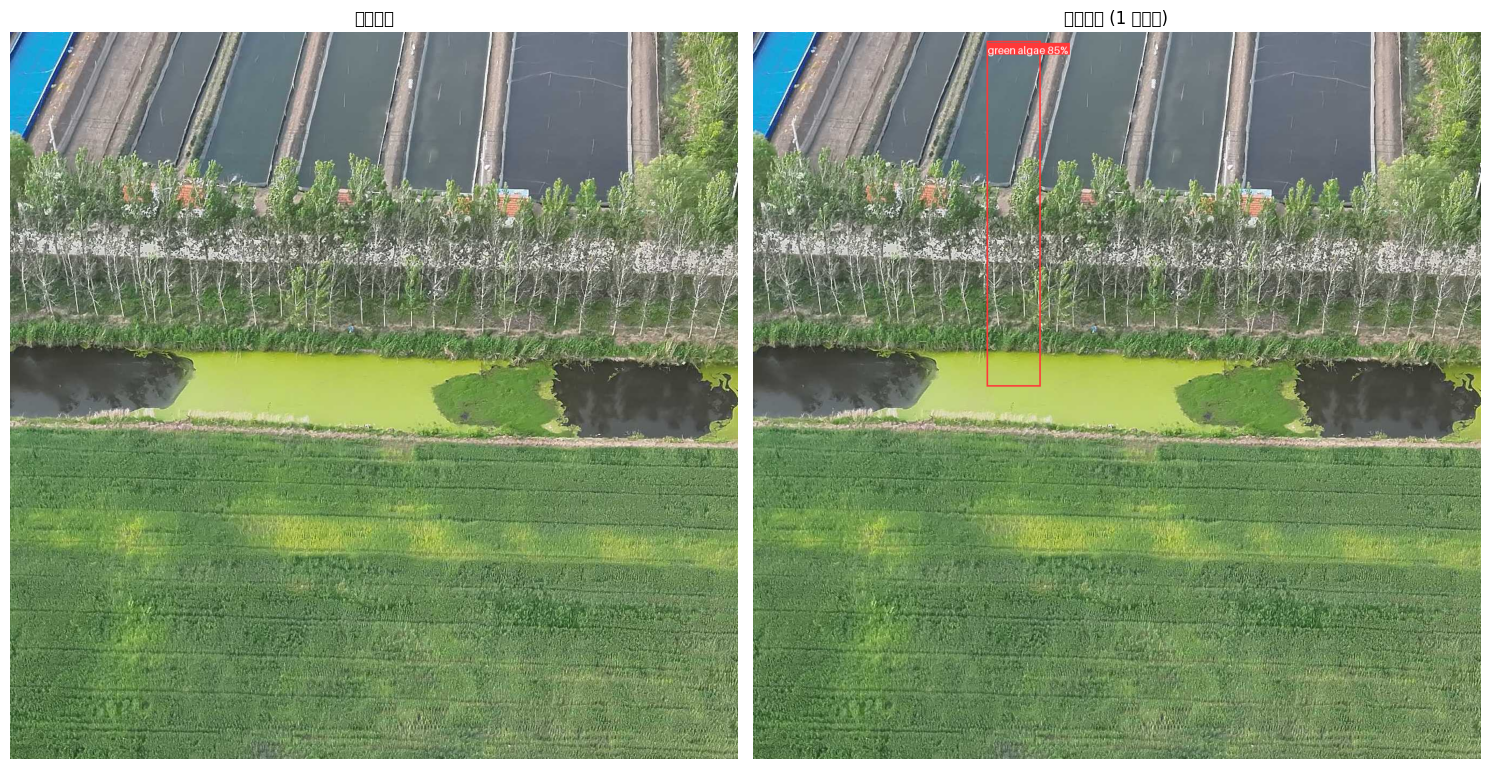


检测结果详情:
  1. green algae - 置信度 85%
     边界框: [434, 18, 534, 660]

测试成功!


{'image_source': 'https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823',
 'query': '检测图中的水面绿藻, 使用green algae作为标签',
 'success': True,
 'image_size': (1353, 1353),
 'raw_response': '```json\n[\n  {"box_2d": [434, 18, 534, 660], "label": "green algae"}\n]\n```',
 'detections': [{'bbox': [434, 18, 534, 660],
   'label': 'green algae',
   'confidence': 0.85}],
 'num_detections': 1,
 'result_image': <PIL.Image.Image image mode=RGB size=1353x1353>}

In [14]:
# 运行测试示例
run_test()

In [15]:
# 运行交互式检测
# interactive_detection()

---

# 附录: 错误处理参考

## 常见错误及解决方案

| 错误类型 | 可能原因 | 解决方案 |
|----------|----------|----------|
| `FileNotFoundError` | 图像路径错误 | 检查路径是否正确 |
| `requests.RequestException` | 网络请求失败 | 检查网络连接或使用本地图片 |
| `ValueError: 不支持的格式` | 图像格式不支持 | 使用 jpg/png 等常见格式 |
| `模型未加载` | 模型初始化失败 | 检查模型路径和配置 |
| `未检测到目标` | 模型未找到指定对象 | 尝试不同的查询或检查图像 |

## 注意事项
1. 确保模型路径正确，LoRA adapter 路径可选
2. 图像 URL 需要可公开访问
3. 检测查询建议使用标准格式 '检测图中的xxx'
4. 首次运行需要先调用 `pipeline.initialize()` 加载模型